# BERT - Forward Pass

<br></br>

## Author: Dr Partha Majumdar
#### ORC-ID: 0009-0002-7375-8034

In [1]:
!pip install -qq prettytable

In [2]:
import numpy as np
import pandas as pd

np.set_printoptions(precision=4, suppress=True)

In [3]:
def pretty_print(df, title="", decimals=3):
    print(f"\n{title}")

    # Round values
    df_rounded = df.round(decimals)

    # Convert to string without scientific notation
    with pd.option_context(
        'display.float_format', f'{{:.{decimals}f}}'.format,
        'display.colheader_justify', 'center'
    ):
        print(df_rounded.to_string())

# STEP 1: Define a toy BERT input

In [4]:
sentence = "I went to the bank to withdraw money."
tokens = sentence.replace(".", " .").split()
tokens = ["[CLS]"] + list(set(tokens)) + ["[SEP]"]
seq_len = len(tokens)
d_model = 4   # small hidden size for illustration
num_heads = 2
d_k = d_model // num_heads

print("STEP 1: Input Tokens")
print(tokens)
print("Sequence length =", seq_len)
print("Hidden dimension =", d_model)

STEP 1: Input Tokens
['[CLS]', 'the', '.', 'to', 'withdraw', 'went', 'money', 'I', 'bank', '[SEP]']
Sequence length = 10
Hidden dimension = 4


For clarity, we construct tokens directly from the sentence using a simple rule-based approach. In practice, BERT uses subword tokenisation, but introducing that at this stage would obscure the core idea of the forward pass.

In actual BERT implementations, tokenisation is performed using WordPiece, which may split words such as 'withdraw' into subword units like 'with' and '##draw'.

# STEP 2: Create toy token embeddings, positional embeddings, and segment embeddings

In [5]:
np.random.seed(42)

token_embeddings = np.random.randn(seq_len, d_model)
position_embeddings = np.random.randn(seq_len, d_model)
segment_embeddings = np.zeros((seq_len, d_model))  # single sentence

# Labels
rows = tokens
cols = [f"h{i+1}" for i in range(d_model)]

# Convert to DataFrames
df_token = pd.DataFrame(token_embeddings, index=rows, columns=cols)
df_position = pd.DataFrame(position_embeddings, index=rows, columns=cols)
df_segment = pd.DataFrame(segment_embeddings, index=rows, columns=cols)

print("STEP 2: Embedding Components")

print("\nToken Embeddings:")
print(df_token)

print("\nPosition Embeddings:")
print(df_position)

print("\nSegment Embeddings:")
print(df_segment)

# Final Input Embedding
X = token_embeddings + position_embeddings + segment_embeddings
df_input = pd.DataFrame(X, index=rows, columns=cols)

print("\nFinal Input Embeddings (Token + Position + Segment):")
print(df_input)

STEP 2: Embedding Components

Token Embeddings:
                h1        h2        h3        h4
[CLS]     0.496714 -0.138264  0.647689  1.523030
the      -0.234153 -0.234137  1.579213  0.767435
.        -0.469474  0.542560 -0.463418 -0.465730
to        0.241962 -1.913280 -1.724918 -0.562288
withdraw -1.012831  0.314247 -0.908024 -1.412304
went      1.465649 -0.225776  0.067528 -1.424748
money    -0.544383  0.110923 -1.150994  0.375698
I        -0.600639 -0.291694 -0.601707  1.852278
bank     -0.013497 -1.057711  0.822545 -1.220844
[SEP]     0.208864 -1.959670 -1.328186  0.196861

Position Embeddings:
                h1        h2        h3        h4
[CLS]     0.738467  0.171368 -0.115648 -0.301104
the      -1.478522 -0.719844 -0.460639  1.057122
.         0.343618 -1.763040  0.324084 -0.385082
to       -0.676922  0.611676  1.031000  0.931280
withdraw -0.839218 -0.309212  0.331263  0.975545
went     -0.479174 -0.185659 -1.106335 -1.196207
money     0.812526  1.356240 -0.072010  1.003533

# STEP 3: Initialise projection matrices for Q, K, V

In [6]:
W_Q = np.random.randn(d_model, d_model)
W_K = np.random.randn(d_model, d_model)
W_V = np.random.randn(d_model, d_model)
W_O = np.random.randn(d_model, d_model)

print("STEP 3: Projection Matrices")

# Create readable labels
rows = [f"h{i+1}" for i in range(d_model)]
cols = [f"h{i+1}" for i in range(d_model)]

df_WQ = pd.DataFrame(W_Q, index=rows, columns=cols)
df_WK = pd.DataFrame(W_K, index=rows, columns=cols)
df_WV = pd.DataFrame(W_V, index=rows, columns=cols)
df_WO = pd.DataFrame(W_O, index=rows, columns=cols)

print("\nW_Q (Query Projection Matrix):")
print(df_WQ)

print("\nW_K (Key Projection Matrix):")
print(df_WK)

print("\nW_V (Value Projection Matrix):")
print(df_WV)

print("\nW_O (Output Projection Matrix):")
print(df_WO)

STEP 3: Projection Matrices

W_Q (Query Projection Matrix):
          h1        h2        h3        h4
h1 -0.219672  0.357113  1.477894 -0.518270
h2 -0.808494 -0.501757  0.915402  0.328751
h3 -0.529760  0.513267  0.097078  0.968645
h4 -0.702053 -0.327662 -0.392108 -1.463515

W_K (Key Projection Matrix):
          h1        h2        h3        h4
h1  0.296120  0.261055  0.005113 -0.234587
h2 -1.415371 -0.420645 -0.342715 -0.802277
h3 -0.161286  0.404051  1.886186  0.174578
h4  0.257550 -0.074446 -1.918771 -0.026514

W_V (Value Projection Matrix):
          h1        h2        h3        h4
h1  0.060230  2.463242 -0.192361  0.301547
h2 -0.034712 -1.168678  1.142823  0.751933
h3  0.791032 -0.909387  1.402794 -1.401851
h4  0.586857  2.190456 -0.990536 -0.566298

W_O (Output Projection Matrix):
          h1        h2        h3        h4
h1  0.099651 -0.503476 -1.550663  0.068563
h2 -1.062304  0.473592 -0.919424  1.549934
h3 -0.783253 -0.322062  0.813517 -1.230864
h4  0.227460  1.307143 -1.60

# STEP 4: Compute Q, K, V

In [7]:
Q = X @ W_Q
K = X @ W_K
V = X @ W_V

print("\nSTEP 4: Query, Key, Value Matrices")

# Create labels
rows = tokens
cols = [f"h{i+1}" for i in range(d_model)]

df_Q = pd.DataFrame(Q, index=rows, columns=cols)
df_K = pd.DataFrame(K, index=rows, columns=cols)
df_V = pd.DataFrame(V, index=rows, columns=cols)

print("\nQ Matrix (Query):")
print(df_Q)

print("\nK Matrix (Key):")
print(df_K)

print("\nV Matrix (Value):")
print(df_V)


STEP 4: Query, Key, Value Matrices

Q Matrix (Query):
                h1        h2        h3        h4
[CLS]    -1.437810  0.297188  1.428292 -1.902223
the      -0.725998 -0.156662 -4.011264 -1.012759
.         1.685526  0.774703 -0.983148  0.774204
to        1.256445  0.020689 -2.046364 -1.414664
withdraw  1.014945 -0.816839 -2.617257  1.042043
went      2.506310  0.884325  2.008129  2.183051
money    -1.565490 -1.720052  1.079797 -2.859821
I        -1.442964 -0.849520 -2.563481 -5.378663
bank      0.833146 -1.063697  0.373113 -0.964775
[SEP]     3.673304  1.191111 -1.048152  0.527166

K Matrix (Key):
                h1        h2        h3        h4
[CLS]     0.547805  0.432529 -1.346099 -0.255832
the       1.132584  0.270315 -1.072883  1.314031
.         1.493509  0.487575  1.787337  1.006921
to        1.920405  0.126117 -1.573017  1.015357
withdraw -0.575020 -0.686131 -0.261034  0.341318
went      0.366965  0.205981  3.215679 -0.013190
money    -1.444702 -1.143989 -5.454688 -1.4900

Observe how the same token now has three different representations — one as Query, one as Key, and one as Value. These are not arbitrary duplications, but specialised projections that allow the model to compare, retrieve, and aggregate contextual information.

# STEP 4A: Single-token walkthrough

In [8]:
print("STEP 4A: Single-token walkthrough")

bank_index = tokens.index("bank")

print("\nToken: 'bank'")
print("Input embedding:", X[bank_index])

print("\nQ vector:", Q[bank_index])
print("K vector:", K[bank_index])
print("V vector:", V[bank_index])

STEP 4A: Single-token walkthrough

Token: 'bank'
Input embedding: [-0.0493  0.5069 -1.7972 -0.3989]

Q vector: [ 0.8331 -1.0637  0.3731 -0.9648]
K vector: [-0.545  -0.9226 -2.7984 -0.6983]
V vector: [-1.6763  0.0466 -1.5371  3.1116]


# STEP 5: Split into Attention Heads

In [9]:
def split_heads(matrix, num_heads):
    return np.split(matrix, num_heads, axis=1)

Q_heads = split_heads(Q, num_heads)
K_heads = split_heads(K, num_heads)
V_heads = split_heads(V, num_heads)

print("STEP 5: Split into Attention Heads")

for i in range(num_heads):
    print(f"\nHead {i+1}:")

    cols = [f"h{j+1}" for j in range(i * d_k, (i + 1) * d_k)]

    df_Qh = pd.DataFrame(Q_heads[i], index=tokens, columns=cols)
    df_Kh = pd.DataFrame(K_heads[i], index=tokens, columns=cols)
    df_Vh = pd.DataFrame(V_heads[i], index=tokens, columns=cols)

    print("\nQ_head:")
    print(df_Qh)

    print("\nK_head:")
    print(df_Kh)

    print("\nV_head:")
    print(df_Vh)

STEP 5: Split into Attention Heads

Head 1:

Q_head:
                h1        h2
[CLS]    -1.437810  0.297188
the      -0.725998 -0.156662
.         1.685526  0.774703
to        1.256445  0.020689
withdraw  1.014945 -0.816839
went      2.506310  0.884325
money    -1.565490 -1.720052
I        -1.442964 -0.849520
bank      0.833146 -1.063697
[SEP]     3.673304  1.191111

K_head:
                h1        h2
[CLS]     0.547805  0.432529
the       1.132584  0.270315
.         1.493509  0.487575
to        1.920405  0.126117
withdraw -0.575020 -0.686131
went      0.366965  0.205981
money    -1.444702 -1.143989
I         2.167101 -0.017820
bank     -0.544988 -0.922576
[SEP]     3.022711  0.661083

V_head:
                h1        h2
[CLS]     1.211203  5.196606
the       1.885542 -0.124443
.        -0.574738 -0.620623
to       -0.313382  1.889047
withdraw -0.824275 -5.000130
went     -2.286158 -1.885646
money    -0.192801  3.079189
I         1.817660  8.150982
bank     -1.676331  0.046552
[

Each attention head operates on a different subspace of the embedding. Instead of one large attention computation, BERT performs multiple smaller attention computations in parallel, each focusing on different aspects of the data.

# STEP 5A: Verification

In [10]:
print("Verification:")
print("Original Q shape:", Q.shape)
print("Sum of split Q_heads widths:", sum([h.shape[1] for h in Q_heads]))

Verification:
Original Q shape: (10, 4)
Sum of split Q_heads widths: 4


Multi-head attention is not about repeating the same computation. It is about allowing the model to look at the same sentence through multiple representational lenses simultaneously.

# STEP 6: Scaled Dot-Product Attention for each head

In [11]:
def softmax(x):
    x_shifted = x - np.max(x, axis=-1, keepdims=True)
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

head_outputs = []
attention_weights_all = []

print("STEP 6: Scaled Dot-Product Attention")

for i in range(num_heads):
    print(f"\n===== Head {i+1} =====")

    # Step 6.1: Scores
    scores = (Q_heads[i] @ K_heads[i].T) / np.sqrt(d_k)
    df_scores = pd.DataFrame(scores, index=tokens, columns=tokens)

    pretty_print(df_scores, "Attention Scores (QK^T / sqrt(d_k))", decimals=3)

    # Step 6.2: Softmax Weights
    attention_weights = softmax(scores)
    df_weights = pd.DataFrame(attention_weights, index=tokens, columns=tokens)

    pretty_print(df_weights, "Attention Weights (after softmax)", decimals=4)

    # Step 6.3: Head Output
    head_output = attention_weights @ V_heads[i]

    cols = [f"h{j+1}" for j in range(i * d_k, (i + 1) * d_k)]
    df_head_output = pd.DataFrame(head_output, index=tokens, columns=cols)

    pretty_print(df_head_output, "Head Output (Weighted sum of V)", decimals=3)

    attention_weights_all.append(attention_weights)
    head_outputs.append(head_output)

STEP 6: Scaled Dot-Product Attention

===== Head 1 =====

Attention Scores (QK^T / sqrt(d_k))
          [CLS]   the     .     to    withdraw  went   money    I    bank   [SEP]
[CLS]    -0.466 -1.095 -1.416 -1.926    0.440  -0.330  1.228 -2.207  0.360 -2.934
the      -0.329 -0.611 -0.821 -1.000    0.371  -0.211  0.868 -1.111  0.382 -1.625
.         0.890  1.498  2.047  2.358   -1.061   0.550 -2.349  2.573 -1.155  3.965
to        0.493  1.010  1.334  1.708   -0.521   0.329 -1.300  1.925 -0.498  2.695
withdraw  0.143  0.657  0.790  1.305   -0.016   0.144 -0.376  1.566  0.142  1.787
went      1.241  2.176  2.952  3.482   -1.448   0.779 -3.276  3.829 -1.543  5.770
money    -1.132 -1.583 -2.246 -2.279    1.471  -0.657  2.991 -2.377  1.725 -4.150
I        -0.819 -1.318 -1.817 -2.035    0.999  -0.498  2.161 -2.200  1.110 -3.481
bank     -0.003  0.464  0.513  1.036    0.177   0.061  0.009  1.290  0.373  1.284
[SEP]     1.787  3.169  4.290  5.094   -2.071   1.127 -4.716  5.614 -2.193  8.408

Att

# STEP 7: Concatenate heads and apply output projection

In [12]:
multihead_output = np.concatenate(head_outputs, axis=1)
attention_output = multihead_output @ W_O

print("STEP 7: Multi-Head Attention Output")
df_attention = pd.DataFrame(attention_output, index=tokens, columns=[f"h{i+1}" for i in range(d_model)])
print(df_attention)

STEP 7: Multi-Head Attention Output
                h1        h2        h3        h4
[CLS]    -0.393628  3.897730 -3.719542  1.116274
the       2.221103 -0.342643 -0.519536  5.874390
.         0.892700  0.362476 -0.870102  7.253745
to        0.063445  2.560488 -3.949765  6.459600
withdraw  0.913206 -0.358309 -1.666641  8.477648
went     -0.291281  3.523351 -2.655528  4.018606
money    -1.055972  4.136736 -4.247565  2.212592
I         0.552674  3.970247 -4.563336  3.633967
bank     -1.202353  2.820141 -3.944787  4.032349
[SEP]     1.539859  0.611145  0.791688  6.076258


# STEP 8: Add & Layer Normalisation

In [13]:
def layer_norm(x, eps=1e-6):
    mean = np.mean(x, axis=1, keepdims=True)
    std = np.std(x, axis=1, keepdims=True)
    return (x - mean) / (std + eps)

Z1 = layer_norm(X + attention_output)

print("STEP 8: After Add & LayerNorm")
df_z1 = pd.DataFrame(Z1, index=tokens, columns=[f"h{i+1}" for i in range(d_model)])
print(df_z1)

STEP 8: After Add & LayerNorm
                h1        h2        h3        h4
[CLS]    -0.052677  1.116228 -1.577167  0.513616
the      -0.397389 -0.921346 -0.371087  1.689821
.        -0.185445 -0.724728 -0.774988  1.685162
to       -0.277295  0.119430 -1.316843  1.474709
withdraw -0.509882 -0.365308 -0.831970  1.707160
went      0.126533  1.089407 -1.622348  0.406407
money    -0.357056  1.142263 -1.455494  0.670287
I        -0.250749  0.381729 -1.440777  1.309797
bank     -0.324277  0.869873 -1.495362  0.949766
[SEP]     0.365174 -1.170131 -0.639985  1.444942


# STEP 9: Feed-Forward Network

In [14]:
W1 = np.random.randn(d_model, d_model * 2)
b1 = np.random.randn(d_model * 2)
W2 = np.random.randn(d_model * 2, d_model)
b2 = np.random.randn(d_model)

FFN_hidden = np.maximum(0, Z1 @ W1 + b1)   # ReLU
FFN_output = FFN_hidden @ W2 + b2

print("STEP 9: Feed-Forward Output")
df_ffn = pd.DataFrame(FFN_output, index=tokens, columns=[f"h{i+1}" for i in range(d_model)])
print(df_ffn)

STEP 9: Feed-Forward Output
                h1        h2        h3        h4
[CLS]    -3.088162  1.232944  1.185568 -2.024187
the      -2.921260  1.171193 -0.177549 -2.755765
.        -3.376785  0.755839  0.052710 -3.112661
to       -3.491733  0.763584  0.051962 -3.265229
withdraw -3.491718  0.587743 -0.067460 -3.321503
went     -3.184957  1.048427  1.173056 -1.765721
money    -3.134356  1.138030  1.088163 -2.225951
I        -3.501667  0.758420  0.047936 -3.280281
bank     -3.329299  0.939356  0.566395 -2.768339
[SEP]    -3.025629  2.083221  0.375110 -2.442519


# STEP 10: Second Add & LayerNorm

In [15]:
Z2 = layer_norm(Z1 + FFN_output)

print("STEP 10: Final Output of One Encoder Block")
df_z2 = pd.DataFrame(Z2, index=tokens, columns=[f"h{i+1}" for i in range(d_model)])
print(df_z2)

STEP 10: Final Output of One Encoder Block
                h1        h2        h3        h4
[CLS]    -1.233517  1.511104  0.140910 -0.418497
the      -1.620167  1.071680  0.469355  0.079131
.        -1.598584  1.083135  0.520879 -0.005429
to       -1.379236  1.430386  0.133156 -0.184306
withdraw -1.569376  1.160484  0.435459 -0.026567
went     -1.265052  1.501442  0.124053 -0.360443
money    -1.295020  1.465245  0.199043 -0.369267
I        -1.289190  1.503546  0.057685 -0.272041
bank     -1.271996  1.501254  0.111180 -0.340438
[SEP]    -1.472895  1.285729  0.376390 -0.189224


# STEP 11: Inspect attention for the word 'bank'

In [16]:
bank_index = tokens.index("bank")

print("STEP 11: Attention Weights for token 'bank'")
for i in range(num_heads):
    attention_to_others = attention_weights_all[i][bank_index]
    df_bank_attention = pd.DataFrame({
        "Token": tokens,
        "Attention_Weight": attention_to_others
    }).sort_values(by="Attention_Weight", ascending=False).reset_index(drop=True)

    print(f"\nHead {i+1} attention from 'bank':")
    print(df_bank_attention)

STEP 11: Attention Weights for token 'bank'

Head 1 attention from 'bank':
      Token  Attention_Weight
0         I          0.190831
1     [SEP]          0.189581
2        to          0.148086
3         .          0.087745
4       the          0.083531
5      bank          0.076260
6  withdraw          0.062716
7      went          0.055844
8     money          0.053018
9     [CLS]          0.052389

Head 2 attention from 'bank':
      Token  Attention_Weight
0      went          0.315504
1     [CLS]          0.111739
2         .          0.107922
3      bank          0.103014
4  withdraw          0.098994
5     money          0.087722
6     [SEP]          0.075087
7        to          0.044216
8       the          0.041153
9         I          0.014647


# STEP 12: Simulate a Masked Language Modelling output

In [17]:
masked_tokens = ["[CLS]", "I", "went", "to", "the", "[MASK]", "to", "withdraw", "money", ".", "[SEP]"]
mask_index = masked_tokens.index("[MASK]")

# Final contextual representation at the [MASK] position
h_mask = Z2[mask_index]

# Toy MLM output layer
W_vocab = np.random.randn(d_model, len(tokens))
b_vocab = np.random.randn(len(tokens))

logits = h_mask @ W_vocab + b_vocab
probs = softmax(logits.reshape(1, -1)).flatten()

df_probs = pd.DataFrame({
    "Word": tokens,
    "Probability": probs
}).sort_values(by="Probability", ascending=False).reset_index(drop=True)

print("STEP 12: Masked Language Modelling Prediction")
print("Masked sentence:")
print(masked_tokens)
print("\nPredicted vocabulary distribution:")
print(df_probs)

STEP 12: Masked Language Modelling Prediction
Masked sentence:
['[CLS]', 'I', 'went', 'to', 'the', '[MASK]', 'to', 'withdraw', 'money', '.', '[SEP]']

Predicted vocabulary distribution:
       Word  Probability
0  withdraw     0.784469
1       the     0.146261
2         I     0.021978
3     [SEP]     0.020588
4        to     0.011888
5      bank     0.009328
6      went     0.003197
7     money     0.002009
8     [CLS]     0.000151
9         .     0.000130


At this stage, the predicted word for the [MASK] is 'to' because the model weights are randomly initialised and no learning has taken place. During actual training, the model repeatedly adjusts its weights using the masked language modelling objective. After sufficient training on large corpora, the same forward pass would assign the highest probability to contextually appropriate words such as 'bank', demonstrating that meaning has been learned from data rather than hardcoded.

# STEP 13: Draw the BERT Forward Pass Neural Network

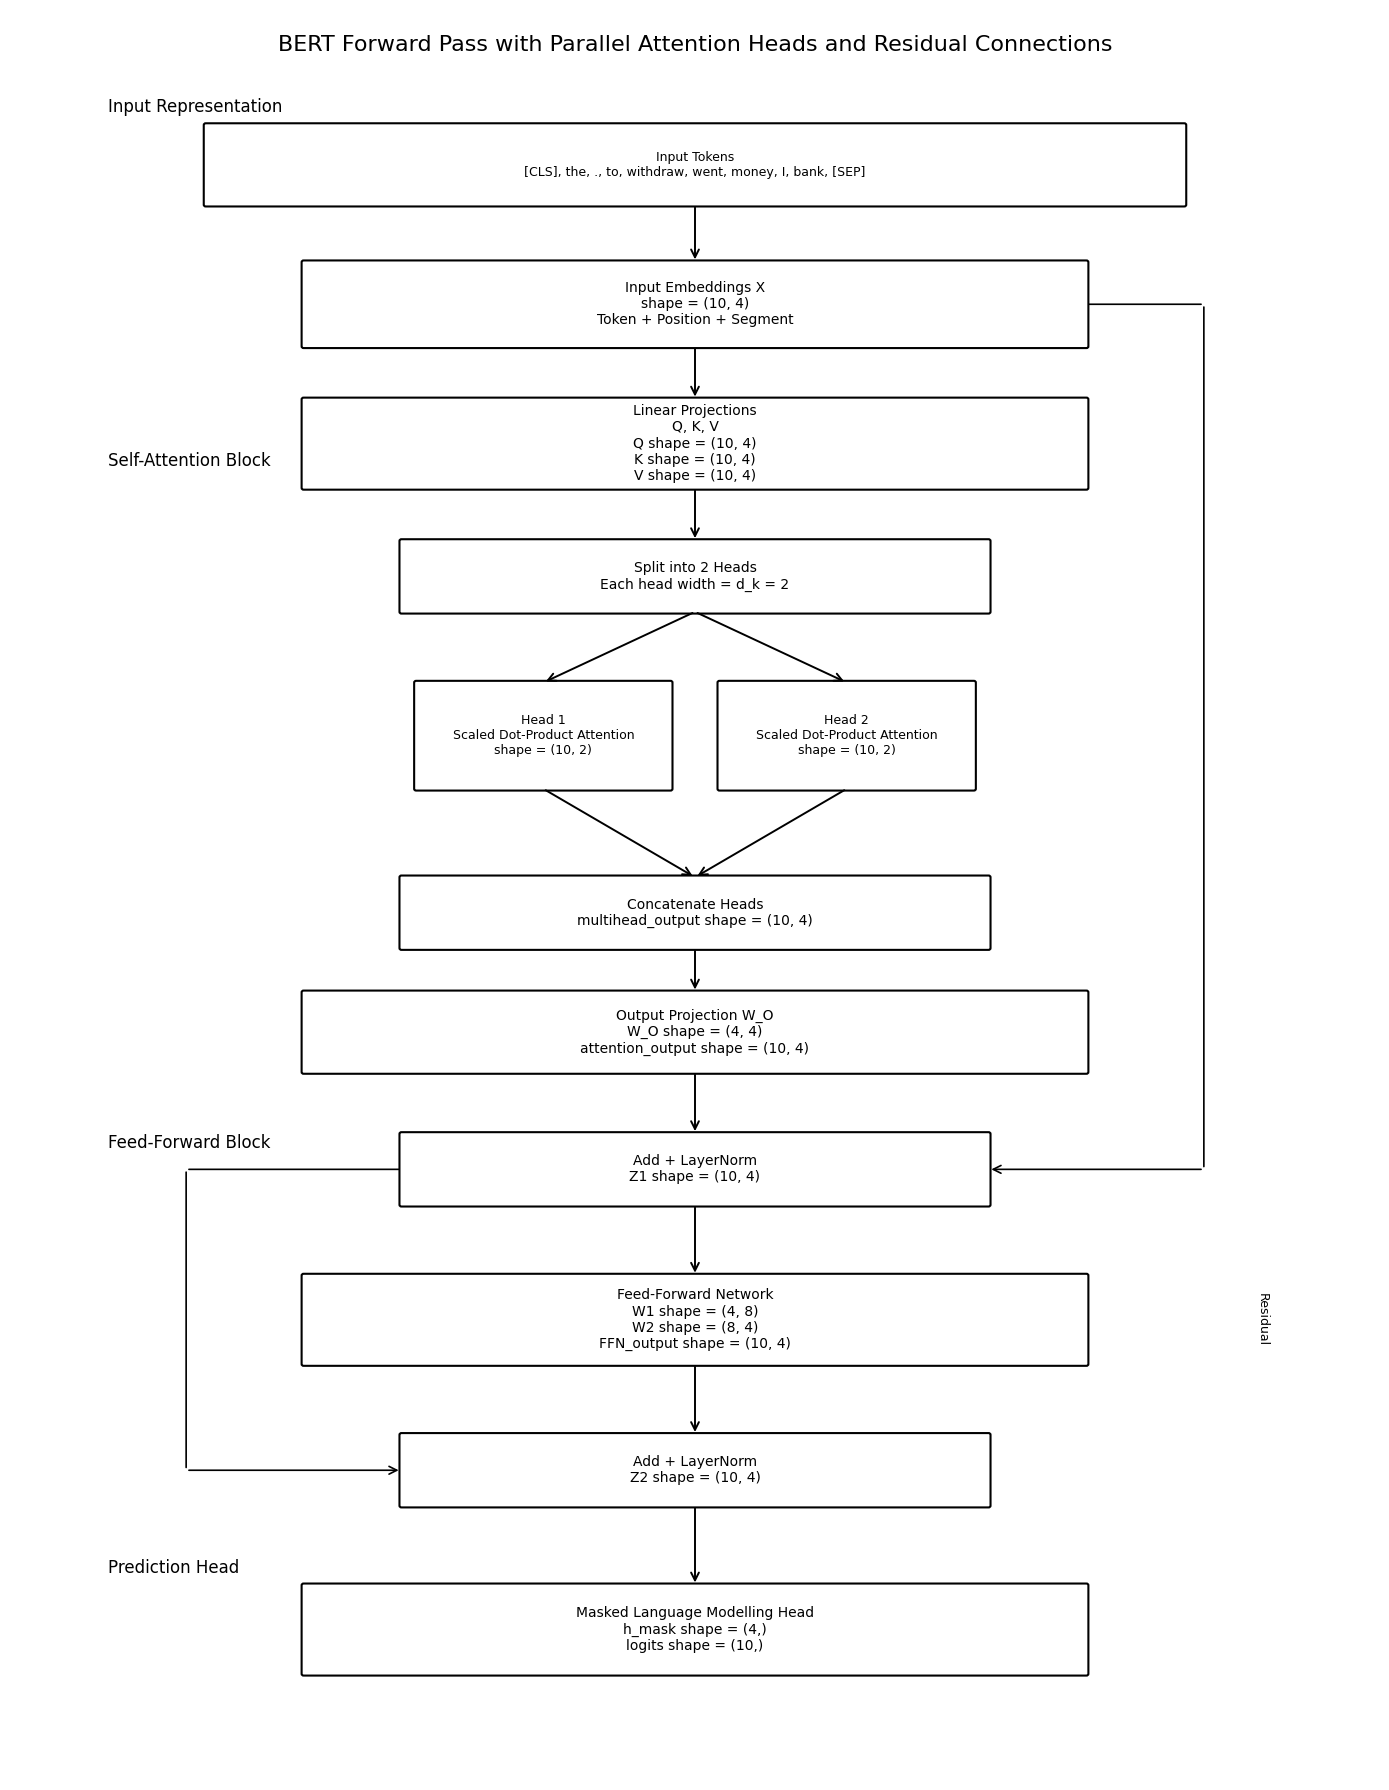

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def add_box(ax, x, y, w, h, text, fontsize=10, lw=1.5):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02",
        linewidth=lw,
        edgecolor="black",
        facecolor="white"
    )
    ax.add_patch(patch)
    ax.text(
        x + w / 2, y + h / 2, text,
        ha="center", va="center",
        fontsize=fontsize,
        wrap=True
    )
    return patch

def add_arrow(ax, start, end, lw=1.4, style="->", mutation=14):
    arrow = FancyArrowPatch(
        start, end,
        arrowstyle=style,
        mutation_scale=mutation,
        linewidth=lw,
        color="black"
    )
    ax.add_patch(arrow)

def top_center(box):
    return (box.get_x() + box.get_width() / 2, box.get_y() + box.get_height())

def bottom_center(box):
    return (box.get_x() + box.get_width() / 2, box.get_y())

def left_center(box):
    return (box.get_x(), box.get_y() + box.get_height() / 2)

def right_center(box):
    return (box.get_x() + box.get_width(), box.get_y() + box.get_height() / 2)

def draw_residual_side(ax, source_box, target_box, x_side, side="right", lw=1.2):
    if side == "right":
        sx, sy = right_center(source_box)
        tx, ty = right_center(target_box)
    else:
        sx, sy = left_center(source_box)
        tx, ty = left_center(target_box)

    # horizontal from source to side channel
    add_arrow(ax, (sx, sy), (x_side, sy), lw=lw, style="-", mutation=1)
    # vertical down/up along side channel
    add_arrow(ax, (x_side, sy), (x_side, ty), lw=lw, style="-", mutation=1)
    # horizontal into target
    add_arrow(ax, (x_side, ty), (tx, ty), lw=lw, style="->", mutation=14)

def draw_bert_forward_pass():
    fig, ax = plt.subplots(figsize=(14, 18))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 20)
    ax.axis("off")

    # --------------------------------------------------------
    # Dynamic labels from current variables
    # --------------------------------------------------------
    token_text = "Input Tokens\n" + ", ".join(tokens)

    embed_text = (
        f"Input Embeddings X\n"
        f"shape = ({seq_len}, {d_model})\n"
        f"Token + Position + Segment"
    )

    qkv_text = (
        f"Linear Projections\n"
        f"Q, K, V\n"
        f"Q shape = {Q.shape}\n"
        f"K shape = {K.shape}\n"
        f"V shape = {V.shape}"
    )

    split_text = (
        f"Split into {num_heads} Heads\n"
        f"Each head width = d_k = {d_k}"
    )

    head_boxes = []
    for i in range(num_heads):
        head_text = (
            f"Head {i+1}\n"
            f"Scaled Dot-Product Attention\n"
            f"shape = ({seq_len}, {d_k})"
        )
        head_boxes.append(head_text)

    concat_text = (
        f"Concatenate Heads\n"
        f"multihead_output shape = {multihead_output.shape}"
    )

    proj_text = (
        f"Output Projection W_O\n"
        f"W_O shape = {W_O.shape}\n"
        f"attention_output shape = {attention_output.shape}"
    )

    addnorm1_text = f"Add + LayerNorm\nZ1 shape = {Z1.shape}"

    ffn_text = (
        f"Feed-Forward Network\n"
        f"W1 shape = {W1.shape}\n"
        f"W2 shape = {W2.shape}\n"
        f"FFN_output shape = {FFN_output.shape}"
    )

    addnorm2_text = f"Add + LayerNorm\nZ2 shape = {Z2.shape}"

    mlm_text = (
        f"Masked Language Modelling Head\n"
        f"h_mask shape = {h_mask.shape}\n"
        f"logits shape = {logits.shape}"
    )

    # --------------------------------------------------------
    # Section labels
    # --------------------------------------------------------
    ax.text(7, 19.6, "BERT Forward Pass with Parallel Attention Heads and Residual Connections",
            ha="center", va="center", fontsize=16)

    ax.text(1.0, 18.9, "Input Representation", ha="left", va="center", fontsize=12)
    ax.text(1.0, 14.9, "Self-Attention Block", ha="left", va="center", fontsize=12)
    ax.text(1.0, 7.2, "Feed-Forward Block", ha="left", va="center", fontsize=12)
    ax.text(1.0, 2.4, "Prediction Head", ha="left", va="center", fontsize=12)

    # --------------------------------------------------------
    # Main boxes
    # --------------------------------------------------------
    b_tokens = add_box(ax, 2.0, 17.8, 10.0, 0.9, token_text, fontsize=9)
    b_embed  = add_box(ax, 3.0, 16.2, 8.0, 0.95, embed_text, fontsize=10)
    b_qkv    = add_box(ax, 3.0, 14.6, 8.0, 1.0, qkv_text, fontsize=10)
    b_split  = add_box(ax, 4.0, 13.2, 6.0, 0.8, split_text, fontsize=10)

    # Parallel attention heads
    head_width = 2.6
    head_height = 1.2
    head_y = 11.2
    head_gap = 0.5
    total_heads_width = num_heads * head_width + (num_heads - 1) * head_gap
    start_x = (14 - total_heads_width) / 2

    head_patches = []
    for i, txt in enumerate(head_boxes):
        hx = start_x + i * (head_width + head_gap)
        hp = add_box(ax, hx, head_y, head_width, head_height, txt, fontsize=9)
        head_patches.append(hp)

    b_concat = add_box(ax, 4.0, 9.4, 6.0, 0.8, concat_text, fontsize=10)
    b_proj   = add_box(ax, 3.0, 8.0, 8.0, 0.9, proj_text, fontsize=10)
    b_add1   = add_box(ax, 4.0, 6.5, 6.0, 0.8, addnorm1_text, fontsize=10)
    b_ffn    = add_box(ax, 3.0, 4.7, 8.0, 1.0, ffn_text, fontsize=10)
    b_add2   = add_box(ax, 4.0, 3.1, 6.0, 0.8, addnorm2_text, fontsize=10)
    b_mlm    = add_box(ax, 3.0, 1.2, 8.0, 1.0, mlm_text, fontsize=10)

    # --------------------------------------------------------
    # Straight pipeline arrows
    # --------------------------------------------------------
    add_arrow(ax, bottom_center(b_tokens), top_center(b_embed))
    add_arrow(ax, bottom_center(b_embed), top_center(b_qkv))
    add_arrow(ax, bottom_center(b_qkv), top_center(b_split))

    # Split to heads
    split_bottom = bottom_center(b_split)
    for hp in head_patches:
        add_arrow(ax, split_bottom, top_center(hp))

    # Heads to concat
    for hp in head_patches:
        add_arrow(ax, bottom_center(hp), top_center(b_concat))

    add_arrow(ax, bottom_center(b_concat), top_center(b_proj))
    add_arrow(ax, bottom_center(b_proj), top_center(b_add1))
    add_arrow(ax, bottom_center(b_add1), top_center(b_ffn))
    add_arrow(ax, bottom_center(b_ffn), top_center(b_add2))
    add_arrow(ax, bottom_center(b_add2), top_center(b_mlm))

    # --------------------------------------------------------
    # Residual connections
    # 1) X -> Add&Norm after attention   (right side)
    # 2) Z1 -> Add&Norm after FFN        (left side)
    # --------------------------------------------------------
    draw_residual_side(ax, b_embed, b_add1, x_side=12.2, side="right", lw=1.2)
    draw_residual_side(ax, b_add1, b_add2, x_side=1.8, side="left", lw=1.2)

    # Small residual labels
    ax.text(12.8, (left_center(b_add1)[1] + left_center(b_add2)[1]) / 2,
            "Residual", ha="center", va="center", rotation=270, fontsize=9)

    plt.tight_layout()
    plt.show()

# Call the function
draw_bert_forward_pass()